# 04 -- Lead Velocity Analysis
**B2B Full-Funnel Attribution** | Meta DS V Portfolio

Lead velocity answers: *is pipeline accelerating or decelerating?*

Metrics:
- **LVR** (Lead Velocity Rate) -- MoM % growth in qualified leads
- **Pipeline Velocity** -- (Opps x Win Rate x Avg Deal) / Avg Sales Cycle
- **Marketing Sourced vs Influenced pipeline**
- **Time-to-Revenue** -- first touch to Closed Won


In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = r"C:/Users/syeda/b2b-full-funnel-attribution"
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

import sqlite3
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import Image, display
import config

sns.set_theme(style="whitegrid")
os.makedirs("visuals", exist_ok=True)
conn = sqlite3.connect(config.DB_PATH)
print("Connected | working dir:", os.getcwd())


Connected | working dir: C:\Users\syeda\b2b-full-funnel-attribution


## 1. Lead Velocity Rate (LVR) Trending

In [2]:
from src.lead_velocity import compute_lvr, compute_pipeline_velocity, compute_marketing_pipeline

lvr = compute_lvr(conn)
print("=== Lead Velocity Rate (last 8 months) ===")
cols = ["month","new_leads","mqls","sqls","opps","won","mqls_lvr_pct","opps_lvr_pct"]
print(lvr.tail(8)[cols].to_string(index=False))


=== Lead Velocity Rate (last 8 months) ===
  month  new_leads  mqls  sqls  opps  won  mqls_lvr_pct  opps_lvr_pct
2025-02       3887  1370   577   384  130     -9.451421     -6.796117
2025-03       4193  1489   599   396  112      8.686131      3.125000
2025-04       4079  1584   613   419  130      6.380121      5.808081
2025-05       4168  1669   686   460  149      5.366162      9.785203
2025-06       4205  1636   676   443  139     -1.977232     -3.695652
2025-07       4260  1614   657   439  130     -1.344743     -0.902935
2025-08       4300  1665   647   422  111      3.159851     -3.872437
2025-09       4122  1613   640   406   66     -3.123123     -3.791469


### LVR Visualisation -- Bar + Line Combo

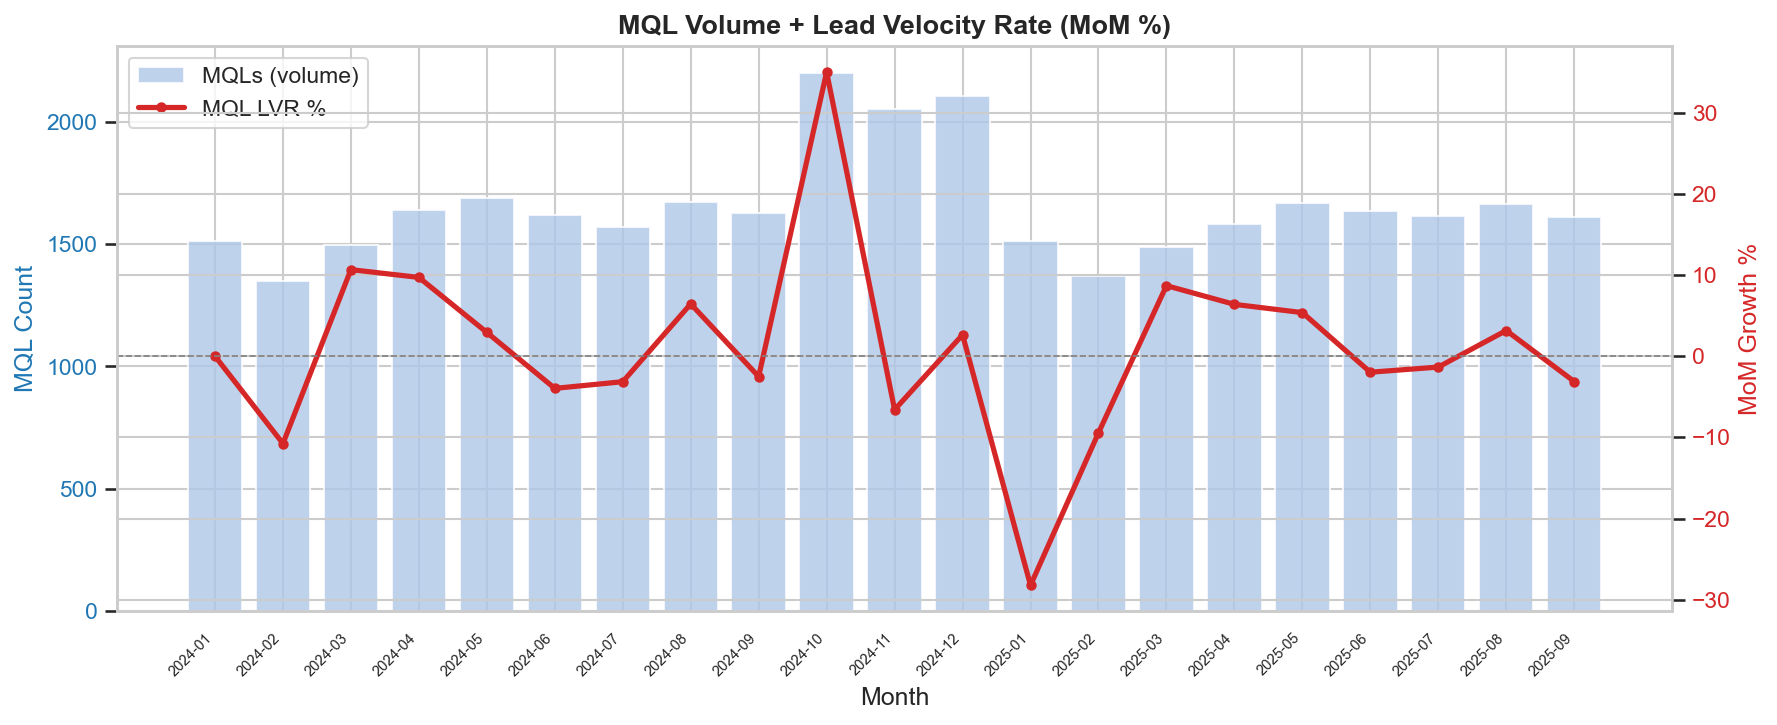

In [3]:
fig, ax1 = plt.subplots(figsize=(12, 5))
x = range(len(lvr))
ax1.bar(x, lvr["mqls"], color="#aec7e8", alpha=0.8, label="MQLs (volume)")
ax1.set_ylabel("MQL Count", color="#1f77b4")
ax1.set_xlabel("Month")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1.set_xticks(list(x))
ax1.set_xticklabels(lvr["month"], rotation=45, ha="right", fontsize=7)

ax2 = ax1.twinx()
ax2.plot(x, lvr["mqls_lvr_pct"].fillna(0), color="#d62728", linewidth=2.5,
         marker="o", markersize=4, label="MQL LVR %")
ax2.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax2.set_ylabel("MoM Growth %", color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="upper left")
plt.title("MQL Volume + Lead Velocity Rate (MoM %)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("visuals/04_lvr_trend.png", dpi=150, bbox_inches="tight")
plt.close()
display(Image("visuals/04_lvr_trend.png"))


## 2. Top 10 Pipeline Velocity Segments

In [4]:
pv = compute_pipeline_velocity(conn)
top10 = pv.head(10)[["company_size","industry","product_line",
                       "n_opps","win_rate","avg_deal","avg_days","pipeline_velocity"]].copy()
top10["avg_deal"]          = top10["avg_deal"].apply(lambda x: f"${x:,.0f}")
top10["pipeline_velocity"] = top10["pipeline_velocity"].apply(lambda x: f"${x:,.0f}/day")
print("=== Top 10 Pipeline Velocity Segments ===")
print(top10.to_string(index=False))


=== Top 10 Pipeline Velocity Segments ===
company_size   industry      product_line  n_opps  win_rate avg_deal  avg_days pipeline_velocity
  Enterprise Technology    Business_Suite      99  0.323232 $301,137 44.717172      $215,496/day
  Enterprise    Finance    Business_Suite      62  0.419355 $298,880 39.500000      $196,731/day
  Enterprise Technology      Ads_Platform      81  0.345679 $305,666 43.814815      $195,337/day
  Enterprise Healthcare    Commerce_Tools      54  0.388889 $309,718 36.981481      $175,874/day
  Enterprise Technology     Messaging_API      89  0.303371 $308,671 48.528090      $171,738/day
  Enterprise Healthcare     Messaging_API      67  0.358209 $305,484 46.164179      $158,816/day
  Enterprise    Finance WhatsApp_Business      63  0.333333 $299,485 40.444444      $155,502/day
  Enterprise Technology WhatsApp_Business      82  0.268293 $318,842 46.548780      $150,692/day
  Enterprise Healthcare    Business_Suite      69  0.333333 $293,155 45.173913      $

## 3. Marketing Sourced vs Influenced Pipeline

=== Marketing Pipeline Attribution ===
                type  opps  pipeline_value  win_rate
Marketing_Influenced   349      36206342.0     0.318
   Marketing_Sourced  8558     888079393.0     0.302
          Sales_Only   238      21458721.0     0.391


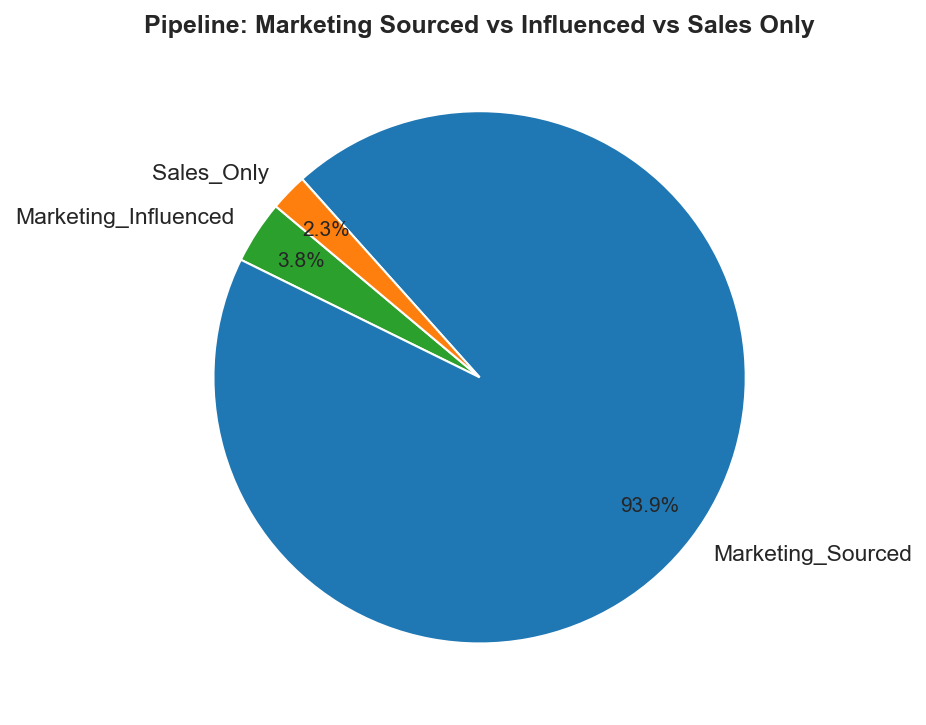

In [5]:
mkt = compute_marketing_pipeline(conn)
print("=== Marketing Pipeline Attribution ===")
print(mkt.to_string(index=False))

labels = mkt["type"].tolist()
sizes  = mkt["pipeline_value"].tolist()
colors = ["#2ca02c","#1f77b4","#ff7f0e"]

fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors,
    autopct="%1.1f%%", startangle=140, pctdistance=0.8
)
for t in autotexts:
    t.set_fontsize(10)
ax.set_title("Pipeline: Marketing Sourced vs Influenced vs Sales Only",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("visuals/04_marketing_pipeline_pie.png", dpi=150, bbox_inches="tight")
plt.close()
display(Image("visuals/04_marketing_pipeline_pie.png"))


## 4. Time-to-Revenue Analysis

=== Time-to-Revenue Analysis ===
  Closed-won contacts analysed: 2,695
  Avg days first touch to Closed Won: 106 days (3.5 months)



=== Time-to-Revenue by First-Touch Channel ===
            channel   n  avg_days
             Events 313     102.2
Content_Syndication 174     102.6
        Paid_Search 335     104.7
     Organic_Search 252     104.9
              Email 407     105.8
            Partner 401     106.5
        Paid_Social 326     107.0
     Outbound_Sales 109     108.1
             Direct 248     108.8
            Webinar 130     110.1


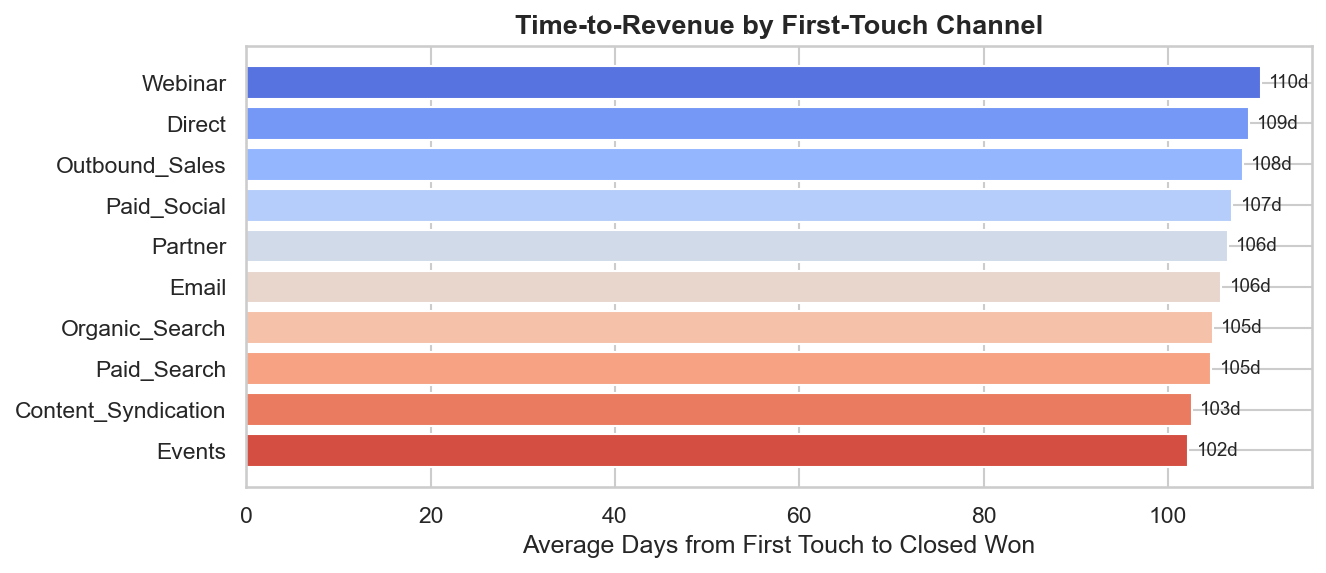


-> Avg sales cycle: 106 days (3.5 months).
   Channels with shorter TTR have higher velocity;
   prioritise them in demand-gen mix.


In [6]:
from src.lead_velocity import compute_time_to_revenue

ttr = compute_time_to_revenue(conn)
avg_days = ttr["avg_days_first_touch_to_revenue"].iloc[0]
n        = ttr["n"].iloc[0]
print(f"=== Time-to-Revenue Analysis ===")
print(f"  Closed-won contacts analysed: {n:,}")
print(f"  Avg days first touch to Closed Won: {avg_days:.0f} days ({avg_days/30:.1f} months)")

ttr_sql = (
    "WITH ranked AS (SELECT contact_id, channel,"
    " MIN(touchpoint_timestamp) AS first_ts,"
    " ROW_NUMBER() OVER (PARTITION BY contact_id ORDER BY MIN(touchpoint_timestamp)) AS rn"
    " FROM touchpoints GROUP BY contact_id, channel),"
    " ft AS (SELECT contact_id, channel, first_ts FROM ranked WHERE rn=1)"
    " SELECT ft.channel, COUNT(*) AS n,"
    " ROUND(AVG(JULIANDAY(c.closed_date)-JULIANDAY(SUBSTR(ft.first_ts,1,10))),1) AS avg_days"
    " FROM ft JOIN contacts c ON c.contact_id=ft.contact_id"
    " WHERE c.lead_status='Closed_Won' AND c.closed_date IS NOT NULL"
    " GROUP BY ft.channel ORDER BY avg_days"
)
ttr_ch = pd.read_sql_query(ttr_sql, conn)
print("\n=== Time-to-Revenue by First-Touch Channel ===")
print(ttr_ch.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(ttr_ch["channel"], ttr_ch["avg_days"],
               color=sns.color_palette("coolwarm_r", len(ttr_ch)))
ax.bar_label(bars, labels=[f"{v:.0f}d" for v in ttr_ch["avg_days"]], padding=4, fontsize=9)
ax.set_xlabel("Average Days from First Touch to Closed Won")
ax.set_title("Time-to-Revenue by First-Touch Channel", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("visuals/04_time_to_revenue.png", dpi=150, bbox_inches="tight")
plt.close()
display(Image("visuals/04_time_to_revenue.png"))

print(f"\n-> Avg sales cycle: {avg_days:.0f} days ({avg_days/30:.1f} months).")
print("   Channels with shorter TTR have higher velocity;")
print("   prioritise them in demand-gen mix.")


In [7]:
conn.close()
print("Done.")


Done.
